In [1]:
# CELL 1: Load processed data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])
fraud_df = fraud_df.drop_duplicates()
print(f"Loaded shape: {fraud_df.shape}")

Loaded shape: (151112, 11)


In [2]:
# IP to Country mapping
def ip_to_int(ip):
    if pd.isna(ip):
        return 0
    try:
        parts = str(ip).split('.')
        if len(parts) != 4:
            return 0
        return (int(parts[0]) << 24) + (int(parts[1]) << 16) + (int(parts[2]) << 8) + int(parts[3])
    except:
        return 0

ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')
fraud_df['ip_int'] = fraud_df['ip_address'].apply(ip_to_int)
ip_df['lower_int'] = ip_df['lower_bound_ip_address'].apply(ip_to_int)
ip_df['upper_int'] = ip_df['upper_bound_ip_address'].apply(ip_to_int)

def get_country(ip_int):
    if ip_int == 0:
        return 'Unknown'
    result = ip_df[(ip_df['lower_int'] <= ip_int) & (ip_df['upper_int'] >= ip_int)]
    return result.iloc[0]['country'] if len(result) > 0 else 'Unknown'

fraud_df['country'] = fraud_df['ip_int'].apply(get_country)
print("Countries added!")
fraud_df[['ip_address', 'country']].head()

Countries added!


,ip_address,country
0,7.327584e+08,Unknown
1,3.503114e+08,Unknown
2,2.621474e+09,Unknown
3,3.840542e+09,Unknown
4,4.155831e+08,Unknown


In [3]:
# Time-based features
fraud_df['hour_of_day'] = fraud_df['purchase_time'].dt.hour
fraud_df['day_of_week'] = fraud_df['purchase_time'].dt.dayofweek
fraud_df['time_since_signup_hours'] = (fraud_df['purchase_time'] - fraud_df['signup_time']).dt.total_seconds() / 3600
fraud_df['new_user_1h'] = (fraud_df['time_since_signup_hours'] <= 1).astype(int)
print("Time features added:")
fraud_df[['hour_of_day', 'day_of_week', 'time_since_signup_hours', 'new_user_1h']].head()

Time features added:


,hour_of_day,day_of_week,time_since_signup_hours,new_user_1h
0,2,5,1251.856111,0
1,1,0,4.984444,0
2,18,3,0.000278,1
3,13,0,136.690278,0
4,18,2,1211.516944,0


In [4]:
# Device-based features
device_users = fraud_df.groupby('device_id')['user_id'].nunique().to_dict()
fraud_df['users_per_device'] = fraud_df['device_id'].map(device_users)
print("Device features added!")
print(fraud_df[['device_id', 'users_per_device']].head())

Device features added!
       device_id  users_per_device
0  QVPSPJUOCKZAR                 1
1  EOGFQPIZPYXFZ                 1
2  YSSKYOSJHPPLJ                12
3  ATGTXKYKUDUQN                 1
4  NAUITBZFJKHWW                 1


In [5]:
# Check feature correlations with fraud
features_to_check = ['purchase_value', 'age', 'hour_of_day', 'day_of_week', 
                     'time_since_signup_hours', 'new_user_1h', 'users_per_device']

print("Correlation with fraud class:")
for feat in features_to_check:
    corr = fraud_df[feat].corr(fraud_df['class'])
    print(f"   {feat}: {corr:.4f}")

Correlation with fraud class:
   purchase_value: 0.0010
   age: 0.0066
   hour_of_day: 0.0020
   day_of_week: 0.0189
   time_since_signup_hours: -0.2579
   new_user_1h: 0.7141
   users_per_device: 0.6708


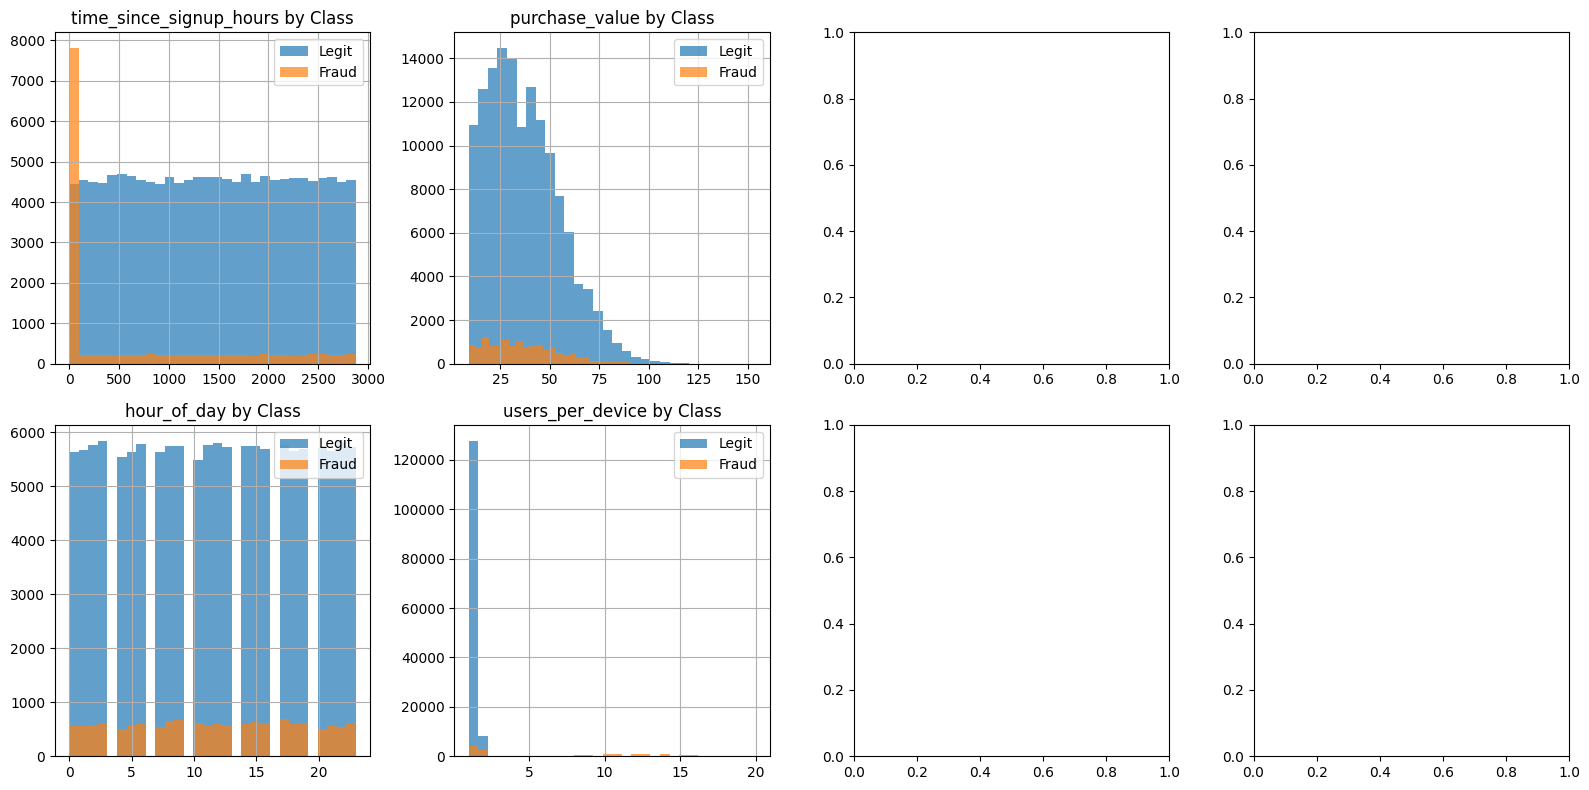

In [6]:
# Visualize feature distributions by class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
features_to_plot = ['time_since_signup_hours', 'purchase_value', 'hour_of_day', 'users_per_device']
for i, feat in enumerate(features_to_plot):
    ax = axes[i//2, i%2]
    fraud_df[fraud_df['class'] == 0][feat].hist(bins=30, alpha=0.7, label='Legit', ax=ax)
    fraud_df[fraud_df['class'] == 1][feat].hist(bins=30, alpha=0.7, label='Fraud', ax=ax)
    ax.set_title(f'{feat} by Class')
    ax.legend()
plt.tight_layout()
plt.savefig('../reports/feature_distributions.png', dpi=100)
plt.show()

In [7]:
# Save processed data with all features
fraud_df.to_csv('../data/processed/fraud_data_processed.csv', index=False)
print(f" Saved: ../data/processed/fraud_data_processed.csv")
print(f"Final shape: {fraud_df.shape}")
print(f"Final columns: {list(fraud_df.columns)}")

 Saved: ../data/processed/fraud_data_processed.csv
Final shape: (151112, 18)
Final columns: ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class', 'ip_int', 'country', 'hour_of_day', 'day_of_week', 'time_since_signup_hours', 'new_user_1h', 'users_per_device']
